In [8]:
from pynq import Overlay, allocate
import numpy as np
import matplotlib.pyplot as plt
import time

In [9]:
print('IP blocks :', list(overlay.ip_dict.keys()))

IP blocks : ['pathtracer_compute_0', 'axi_dma_b', 'axi_dma_g', 'axi_dma_r', 'processing_system7_0']


In [10]:
overlay = Overlay("design_1.bit")

ip = overlay.pathtracer_compute_0
dma_r = overlay.axi_dma_r
dma_g = overlay.axi_dma_g
dma_b = overlay.axi_dma_b

In [11]:
width = 200
height = 200
samples = 10

size = width * height

r = allocate((size,), dtype=np.int32)
g = allocate((size,), dtype=np.int32)
b = allocate((size,), dtype=np.int32)

In [12]:
ip.write(0x10, width)
ip.write(0x18, height)
ip.write(0x20, samples)

t0 = time.time()

dma_r.recvchannel.transfer(r)
dma_g.recvchannel.transfer(g)
dma_b.recvchannel.transfer(b)

ip.write(0x00, 1)

dma_r.recvchannel.wait()
dma_g.recvchannel.wait()
dma_b.recvchannel.wait()

print("Time :", time.time() - t0, "s")

Time : 2.948158025741577 s


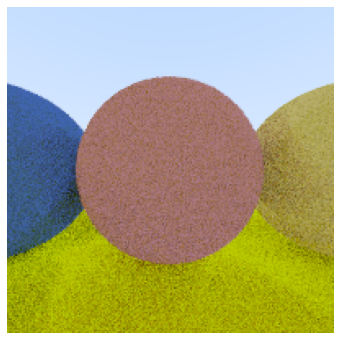

In [13]:
r.invalidate()
g.invalidate()
b.invalidate()

image = np.stack((r, g, b), axis=1)
image = image.reshape(height, width, 3)
image = np.flipud(image)
image = np.clip(image, 0, 255).astype(np.uint8)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.show()

In [14]:
from PIL import Image

Image.fromarray(image).save("pathtracer_hardware.png")